# Inferencia del parámetro $g = h/J$ y fase del TFIM a partir de $|\psi_0\rangle$

$$H = -J \sum_i \sigma^z_i \sigma^z_{i+1} - h \sum_i \sigma^x_i$$

**Objetivo:** dado $|\psi_0\rangle$ con ruido de medida, inferir $g = h/J$, $E_0/J$ y la fase (FM / Crítico / PM).

El estado se perturba con ruido gaussiano para simular errores experimentales:
$$|\tilde{\psi}_0\rangle = \frac{|\psi_0\rangle + \eta\,|\xi\rangle}{\||\psi_0\rangle + \eta\,|\xi\rangle\|}, \qquad |\xi\rangle \sim \mathcal{N}(0, I)$$

El diagrama de fases del TFIM 1D tiene una transición de fase cuántica en $g = 1$:
- $g > 1+\varepsilon$: **Ferromagnético**
- $g < 1-\varepsilon$: **Paramagnético**
- $|g - 1| \leq \varepsilon$: **Crítico**

## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy import sparse

## 2. Hiperparámetros

In [2]:
N          = 12       # Numero de spins (dim Hilbert = 2^N)
BATCH_SIZE = 500
G_RANGE    = (0.1, 2.0)   # Rango de g = h/J
CRIT_EPS   = 0.15         # Region critica: |g - 1| < CRIT_EPS
NOISE_ETA  = 0.015        # Amplitud del ruido en el estado

HIDDEN_DIM = 256
N_LAYERS   = 5

LR         = 1e-3
N_EPOCHS   = 600
PATIENCE   = 50
LAMBDA_REG = 1.0   # peso MSE en (g, E0/h)
LAMBDA_CLS = 0.5   # peso CrossEntropy en fase

PHASE_NAMES  = {0: "Ferromagnetico", 1: "Critico", 2: "Paramagnetico"}
PHASE_COLORS = {0: "#e74c3c",        1: "#f39c12", 2: "#3498db"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device} | N={N} | dim Hilbert={2**N} | ruido eta={NOISE_ETA}")


Dispositivo: cpu | N=12 | dim Hilbert=4096 | ruido η=0.015


## 3. Generación de datos

In [ ]:
from scipy import sparse


def assign_phase(g, eps):
    """0=FM (g>1), 1=Critico (|g-1|<=eps), 2=PM (g<1)"""
    if abs(g - 1.0) <= eps: return 1
    return 0 if g > 1.0 else 2


def build_TFIM_hamiltonian(N, h, J=1.0):
    """
    Construye el Hamiltoniano TFIM con condiciones de contorno periodicas (PBC).
    H = -J * sum(sz_i * sz_{i+1}) - h * sum(sx_i)
    """
    sz = sparse.csr_matrix([[1, 0], [0, -1]], dtype=float)
    sx = sparse.csr_matrix([[0, 1], [1, 0]], dtype=float)
    I = sparse.eye(2, dtype=float)
    
    H = sparse.csr_matrix((2**N, 2**N), dtype=float)
    
    for i in range(N):
        term = sparse.eye(1, dtype=float)
        for site in range(N):
            if site == i or site == (i + 1) % N:
                term = sparse.kron(term, sz, format='csr')
            else:
                term = sparse.kron(term, I, format='csr')
        H -= J * term

    for i in range(N):
        term = sparse.eye(1, dtype=float)
        for site in range(N):
            if site == i:
                term = sparse.kron(term, sx, format='csr')
            else:
                term = sparse.kron(term, I, format='csr')
        H -= h * term
        
    return H

def diagonalize_ground_state(H):
    """Calcula la energia y el autovector del estado fundamental (Lanczos)."""
    evals, evecs = eigsh(H, k=1, which='SA', tol=1e-8)
    return evals[0], evecs[:, 0]


def generate_TFIM_dataset(N, batch_size, g_range, crit_eps, eta, seed=42):
    """
    Genera el dataset muestreando g = h/J uniformemente.
    Anade ruido gaussiano al estado para simular errores de medida.

    Input de la red:  |psi_0> con ruido  (2^N componentes)
    Outputs:
        [g, E0/h]  - regresion
        fase       - clasificacion (0=FM, 1=Critico, 2=PM)
    """
    rng    = np.random.default_rng(seed)
    g_vals = rng.uniform(g_range[0], g_range[1], batch_size)

    dim    = 2**N
    states  = np.zeros((batch_size, dim),  dtype=np.float32)
    targets = np.zeros((batch_size, 2),    dtype=np.float32)   # [g, E0/h]
    phases  = np.zeros(batch_size,          dtype=np.int64)

    for i, g in enumerate(g_vals):
        H = build_TFIM_hamiltonian(N, g, 1.0)   # h=1 fija la escala
        print(f"Diagonalizando muestra {i+1}/{batch_size}...", end="\r")
        evals, evecs = diagonalize_ground_state(H)
        psi0 = evecs.real
        if psi0[np.argmax(np.abs(psi0))] < 0:
            psi0 = -psi0
        if eta > 0:
            psi0 = psi0 + eta * rng.standard_normal(dim)
            psi0 = psi0 / np.linalg.norm(psi0)
        states[i]     = psi0.astype(np.float32)
        targets[i, 0] = g
        targets[i, 1] = evals   # E0/h con h=1
        phases[i]     = assign_phase(g, crit_eps)
        print(f"Generando muestra {i+1}/{batch_size} | g={g:.3f} | E0/h={evals:.3f} | fase={PHASE_NAMES[phases[i]]}", end="\r")

    return states, targets, phases, g_vals


Generando dataset...
Dataset: 500 muestras, dim estado = 4096/h=-15.921 | fase=Críticonéticoo
  Ferromagnético: 233 (46.6%)
  Crítico: 72 (14.4%)
  Paramagnético: 195 (39.0%)


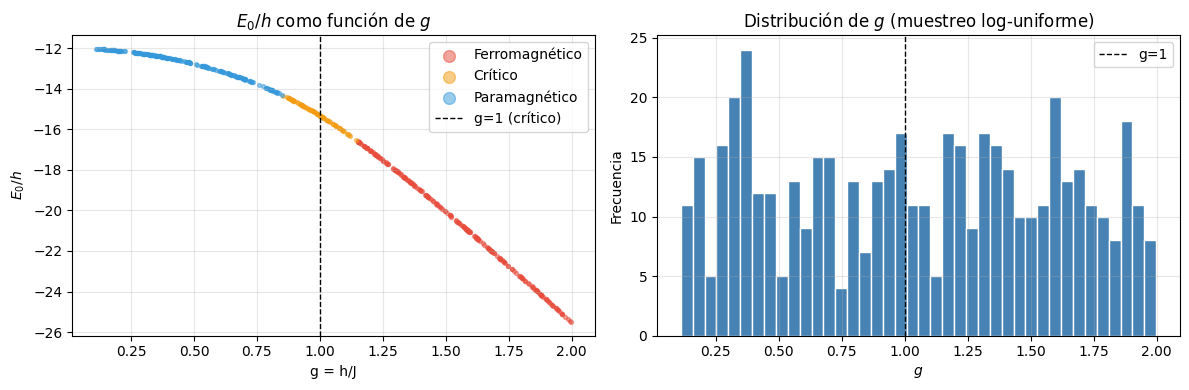

In [15]:
print("Generando dataset...")
states, targets, phases, g_vals = generate_TFIM_dataset(
    N, BATCH_SIZE, G_RANGE, CRIT_EPS, NOISE_ETA
)
print(f"Dataset: {BATCH_SIZE} muestras, dim estado = {2**N}")
for k, name in PHASE_NAMES.items():
    n_k = (phases == k).sum()
    print(f"  {name}: {n_k} ({100*n_k/BATCH_SIZE:.1f}%)")

# Visualización del dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for k, name in PHASE_NAMES.items():
    mask = phases == k
    ax.scatter(g_vals[mask], targets[mask, 1], c=PHASE_COLORS[k], s=8, alpha=0.5, label=name)
ax.axvline(1.0, color='k', linestyle='--', lw=1, label="g=1 (crítico)")
ax.set_xlabel("g = h/J"); ax.set_ylabel("$E_0/h$")
ax.set_title("$E_0/h$ como función de $g$")
ax.legend(markerscale=3); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(g_vals, bins=40, color="steelblue", edgecolor="white")
ax.axvline(1.0, color='k', linestyle='--', lw=1, label="g=1")
ax.set_xlabel("$g$"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de $g$ (muestreo log-uniforme)")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Preprocesado y split train / val / test (70 / 15 / 15)

In [5]:
# Split estratificado para mantener proporción de fases en cada partición
X_train, X_temp, Yr_train, Yr_temp, Yc_train, Yc_temp = train_test_split(
    states, targets, phases, test_size=0.3, random_state=42, stratify=phases
)
X_val, X_test, Yr_val, Yr_test, Yc_val, Yc_test = train_test_split(
    X_temp, Yr_temp, Yc_temp, test_size=0.5, random_state=42, stratify=Yc_temp
)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)

scaler_Y = StandardScaler()
Yr_train = scaler_Y.fit_transform(Yr_train)
Yr_val   = scaler_Y.transform(Yr_val)
Yr_test  = scaler_Y.transform(Yr_test)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Input: {X_train.shape[1]} componentes de |ψ₀⟩")
print(f"Output regresión: [g, E₀/h] | Output clasificación: 3 clases")

Train: 350 | Val: 75 | Test: 75
Input: 4096 componentes de |ψ₀⟩
Output regresión: [g, E₀/h] | Output clasificación: 3 clases


## 5. Modelo — Red con cabeza dual (regresión + clasificación)

```
|ψ₀⟩  (2^N)
   └─► [Linear → LayerNorm → GELU] × n_layers   (tronco compartido)
            ├─► Linear(2)                    →  (g, E₀/h)   [regresión]
            └─► Linear(hidden/2) → GELU → Linear(3)  →  fase  [clasificación]
```

In [6]:
class PhaseNet(nn.Module):
    """
    Red con cabeza dual:
      - Regresión:     |ψ₀⟩ → (g, E₀/h)
      - Clasificación: |ψ₀⟩ → P(FM), P(Crítico), P(PM)
    """
    def __init__(self, input_dim, hidden_dim, n_layers, n_phases=3):
        super().__init__()
        trunk = []
        in_f  = input_dim
        for _ in range(n_layers):
            trunk += [nn.Linear(in_f, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU()]
            in_f = hidden_dim
        self.trunk    = nn.Sequential(*trunk)
        self.head_reg = nn.Linear(hidden_dim, 2)
        self.head_cls = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, n_phases)
        )

    def forward(self, x):
        z = self.trunk(x)
        return self.head_reg(z), self.head_cls(z)


model = PhaseNet(input_dim=2**N, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParámetros entrenables: {n_params:,}")

PhaseNet(
  (trunk): Sequential(
    (0): Linear(in_features=4096, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (8): GELU(approximate='none')
    (9): Linear(in_features=256, out_features=256, bias=True)
    (10): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (11): GELU(approximate='none')
    (12): Linear(in_features=256, out_features=256, bias=True)
    (13): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (14): GELU(approximate='none')
  )
  (head_reg): Linear(in_features=256, out_features=2, bias=True)
  (head_cls): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): 

## 6. Entrenamiento

$$\mathcal{L} = \lambda_\text{reg} \cdot \text{MSE}(g,\, E_0/h) + \lambda_\text{cls} \cdot \text{CrossEntropy}(\text{fase})$$

In [7]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
loss_mse  = nn.MSELoss()
loss_ce   = nn.CrossEntropyLoss()

def to_torch(arr, dtype=torch.float32):
    return torch.tensor(arr, dtype=dtype).to(device)

X_tr  = to_torch(X_train);  Yr_tr = to_torch(Yr_train)
Yc_tr = to_torch(Yc_train, dtype=torch.long)
X_vl  = to_torch(X_val);    Yr_vl = to_torch(Yr_val)
Yc_vl = to_torch(Yc_val, dtype=torch.long)

train_losses, val_losses = [], []
best_val_loss, best_state, epochs_no_improve = float("inf"), None, 0

for epoch in range(N_EPOCHS):
    model.train()
    optimizer.zero_grad()
    out_reg, out_cls = model(X_tr)
    loss = LAMBDA_REG * loss_mse(out_reg, Yr_tr) + LAMBDA_CLS * loss_ce(out_cls, Yc_tr)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        vr, vc   = model(X_vl)
        val_loss = LAMBDA_REG * loss_mse(vr, Yr_vl) + LAMBDA_CLS * loss_ce(vc, Yc_vl)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)

    if epoch % 50 == 0 or epoch == N_EPOCHS - 1:
        print(f"Epoch {epoch:4d} | Train: {loss.item():.5f} | Val: {val_loss.item():.5f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping en epoch {epoch}. Mejor val loss: {best_val_loss:.5f}")
            break

model.load_state_dict(best_state)

Epoch    0 | Train: 1.80057 | Val: 1.05501
Epoch   50 | Train: 0.00101 | Val: 0.10755

Early stopping en epoch 70. Mejor val loss: 0.09037


<All keys matched successfully>

## 7. Evaluación

In [13]:
model.eval()
with torch.no_grad():
    pred_reg_sc, pred_cls_logits = model(to_torch(X_test))

pred_reg = scaler_Y.inverse_transform(pred_reg_sc.cpu().numpy())
true_reg = scaler_Y.inverse_transform(Yr_test)
pred_cls = pred_cls_logits.argmax(dim=1).cpu().numpy()
true_cls = Yc_test

g_pred, Eh_pred = pred_reg[:, 0], pred_reg[:, 1]
g_real, Eh_real = true_reg[:, 0], true_reg[:, 1]

print("=== Regresión ===")
for i, name in enumerate(["g = h/J", "E₀/h"]):
    err = np.abs(pred_reg[:, i] - true_reg[:, i])
    print(f"  Error medio en {name}: {err.mean():.4f} ± {err.std():.4f}")

accuracy = (pred_cls == true_cls).mean()
print(f"\n=== Clasificación ===")
print(f"  Accuracy global: {accuracy:.4f} ({100*accuracy:.1f}%)")
for k, name in PHASE_NAMES.items():
    mask = true_cls == k
    if mask.sum() > 0:
        acc_k = (pred_cls[mask] == true_cls[mask]).mean()
        print(f"  {name}: {acc_k:.4f} ({mask.sum()} muestras)")

=== Regresión ===
  Error medio en g = h/J: 0.1057 ± 0.0691
  Error medio en E₀/h: 0.7838 ± 0.7571

=== Clasificación ===
  Accuracy global: 0.9333 (93.3%)
  Ferromagnético: 1.0000 (35 muestras)
  Crítico: 0.5455 (11 muestras)
  Paramagnético: 1.0000 (29 muestras)


## 8. Visualización

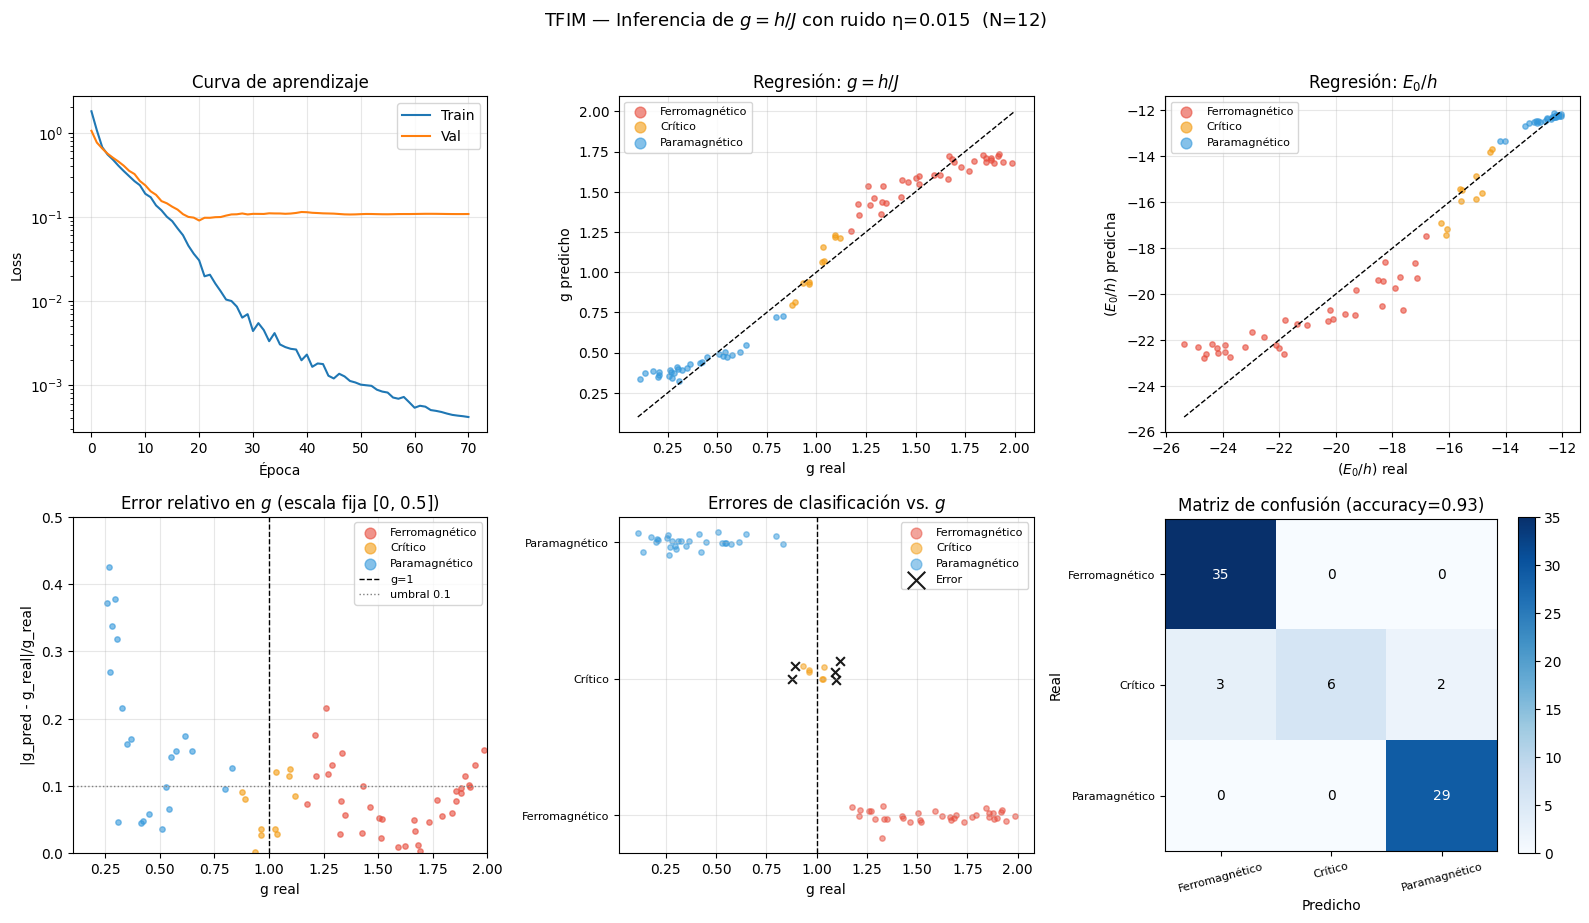

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# --- Curva de pérdida ---
ax = axes[0, 0]
ax.semilogy(train_losses, label="Train")
ax.semilogy(val_losses,   label="Val")
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.set_title("Curva de aprendizaje")
ax.legend(); ax.grid(True, alpha=0.3)

# --- g predicho vs real ---
ax = axes[0, 1]
for k in PHASE_NAMES:
    mask = true_cls == k
    ax.scatter(g_real[mask], g_pred[mask], c=PHASE_COLORS[k], s=15, alpha=0.6, label=PHASE_NAMES[k])
lims = [G_RANGE[0], G_RANGE[1]]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel("g real"); ax.set_ylabel("g predicho")
ax.set_title(f"Regresión: $g = h/J$")
ax.legend(fontsize=8, markerscale=2); ax.grid(True, alpha=0.3)

# --- E0/h predicho vs real ---
ax = axes[0, 2]
for k in PHASE_NAMES:
    mask = true_cls == k
    ax.scatter(Eh_real[mask], Eh_pred[mask], c=PHASE_COLORS[k], s=15, alpha=0.6, label=PHASE_NAMES[k])
lims_e = [min(Eh_real.min(), Eh_pred.min()), max(Eh_real.max(), Eh_pred.max())]
ax.plot(lims_e, lims_e, 'k--', lw=1)
ax.set_xlabel("$(E_0/h)$ real"); ax.set_ylabel("$(E_0/h)$ predicha")
ax.set_title("Regresión: $E_0/h$")
ax.legend(fontsize=8, markerscale=2); ax.grid(True, alpha=0.3)

# --- Error relativo en g vs g real (escala fija) ---
ax = axes[1, 0]
err_g = np.abs(g_pred - g_real)
for k in PHASE_NAMES:
    mask = true_cls == k
    ax.scatter(g_real[mask], err_g[mask]/g_real[mask], c=PHASE_COLORS[k], s=15, alpha=0.6, label=PHASE_NAMES[k])
ax.axvline(1.0, color='k', linestyle='--', lw=1, label="g=1")
ax.axhline(0.1, color='gray', linestyle=':', lw=1, label="umbral 0.1")
ax.set_xlabel("g real"); ax.set_ylabel("|g_pred - g_real|/g_real")
ax.set_ylim(0, 0.5)   # escala fija para juzgar calidad de forma consistente
ax.set_xlim(G_RANGE[0], G_RANGE[1])
ax.set_title("Error relativo en $g$ (escala fija [0, 0.5])")
ax.legend(fontsize=8, markerscale=2); ax.grid(True, alpha=0.3)

# --- Errores de clasificación vs g ---
ax = axes[1, 1]
correct   = pred_cls == true_cls
incorrect = ~correct
for k in PHASE_NAMES:
    mask = (true_cls == k) & correct
    jitter = np.random.randn(mask.sum()) * 0.05
    ax.scatter(g_real[mask], np.zeros(mask.sum()) + k + jitter,
               c=PHASE_COLORS[k], s=15, alpha=0.5, label=PHASE_NAMES[k])
if incorrect.sum() > 0:
    ax.scatter(g_real[incorrect],
               true_cls[incorrect].astype(float) + np.random.randn(incorrect.sum()) * 0.05,
               marker="x", c="black", s=40, alpha=0.9, label="Error")
ax.axvline(1.0, color='k', linestyle='--', lw=1)
ax.set_xlabel("g real"); ax.set_yticks([0, 1, 2])
ax.set_yticklabels([PHASE_NAMES[k] for k in range(3)], fontsize=8)
ax.set_title("Errores de clasificación vs. $g$")
ax.legend(fontsize=8, markerscale=2); ax.grid(True, alpha=0.3)

# --- Matriz de confusión ---
ax = axes[1, 2]
conf_mat = np.zeros((3, 3), dtype=int)
for t, p in zip(true_cls, pred_cls):
    conf_mat[t, p] += 1
im = ax.imshow(conf_mat, cmap="Blues")
labels = [PHASE_NAMES[k] for k in range(3)]
ax.set_xticks(range(3)); ax.set_xticklabels(labels, rotation=15, fontsize=8)
ax.set_yticks(range(3)); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión (accuracy={accuracy:.2f})")
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(conf_mat[i, j]), ha="center", va="center",
                color="white" if conf_mat[i, j] > conf_mat.max() / 2 else "black")
plt.colorbar(im, ax=ax)

plt.suptitle(f"TFIM — Inferencia de $g=h/J$ con ruido η={NOISE_ETA}  (N={N})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 9. Inferencia sobre un estado del test set

Dado un vector de estado $|\psi_0\rangle$, la red predice $g$, $E_0/h$ y la fase con las probabilidades de cada clase.

In [10]:
def predict_from_state(psi, model, scaler_X, scaler_Y, device):
    """
    Dado un vector de estado |ψ₀⟩ (array 1D de longitud 2^N),
    devuelve g, E₀/h y la fase predichos con sus probabilidades.
    """
    psi_n  = psi / (np.linalg.norm(psi) + 1e-12)   # asegura normalización
    psi_sc = scaler_X.transform(psi_n.reshape(1, -1)).astype(np.float32)
    x      = torch.tensor(psi_sc).to(device)

    model.eval()
    with torch.no_grad():
        out_reg, out_cls = model(x)

    reg   = scaler_Y.inverse_transform(out_reg.cpu().numpy())[0]
    phase = out_cls.argmax(dim=1).item()
    probs = torch.softmax(out_cls, dim=1).cpu().numpy()[0]

    print(f"g = J/h predicho:  {reg[0]:.4f}")
    print(f"E₀/h predicha:     {reg[1]:.4f}")
    print(f"Fase predicha:     {PHASE_NAMES[phase]}")
    print(f"Probabilidades:")
    for k, name in PHASE_NAMES.items():
        bar = '█' * int(probs[k] * 30)
        print(f"  {name:>15}: {probs[k]:.3f}  {bar}")
    return reg, phase, probs


# Elegimos un estado aleatorio del test set
rng_infer = np.random.default_rng(7)
i = rng_infer.integers(0, len(X_test))

psi_example = scaler_X.inverse_transform(X_test[i:i+1])[0]
g_true, Eh_true = true_reg[i]

print(f"--- Muestra #{i} del test set ---")
print(f"Valores reales: g={g_true:.4f} | E₀/h={Eh_true:.4f} | Fase={PHASE_NAMES[true_cls[i]]}")
print()
reg_pred, phase_pred, probs_pred = predict_from_state(
    psi_example, model, scaler_X, scaler_Y, device
)
print()
print(f"Error en g:    {abs(reg_pred[0] - g_true):.4f}")
print(f"Error en E₀/h: {abs(reg_pred[1] - Eh_true):.4f}")
print(f"Clasificación: {'✓ correcta' if phase_pred == true_cls[i] else '✗ incorrecta'}")

--- Muestra #70 del test set ---
Valores reales: g=1.5150 | E₀/h=-20.2231 | Fase=Ferromagnético

g = J/h predicho:  1.5484
E₀/h predicha:     -20.6885
Fase predicha:     Ferromagnético
Probabilidades:
   Ferromagnético: 0.999  █████████████████████████████
          Crítico: 0.001  
    Paramagnético: 0.000  

Error en g:    0.0334
Error en E₀/h: 0.4654
Clasificación: ✓ correcta


## 10. Guardar el modelo

In [11]:
torch.save({
    "model_state_dict": model.state_dict(),
    "scaler_X_mean":  scaler_X.mean_,  "scaler_X_scale": scaler_X.scale_,
    "scaler_Y_mean":  scaler_Y.mean_,  "scaler_Y_scale": scaler_Y.scale_,
    "N": N, "hidden_dim": HIDDEN_DIM, "n_layers": N_LAYERS,
    "crit_eps": CRIT_EPS, "noise_eta": NOISE_ETA, "phase_names": PHASE_NAMES,
}, "phase_net_model.pt")
print("Modelo guardado en phase_net_model.pt")

Modelo guardado en phase_net_model.pt


In [12]:
print(N)

12
